# MCQMC 2026 Plenary Talk Running Example

#### Some LaTeX macros (hidden in math mode, will not render correctly in VS Code)
$
\newcommand{\vf}{\boldsymbol{f}}
\newcommand{\vh}{\boldsymbol{h}}
\newcommand{\vt}{\boldsymbol{t}}
\newcommand{\vu}{\boldsymbol{u}}
\newcommand{\vx}{\boldsymbol{x}}
\newcommand{\vy}{\boldsymbol{y}}
\newcommand{\vz}{\boldsymbol{z}}
\newcommand{\vX}{\boldsymbol{X}}
\newcommand{\vU}{\boldsymbol{U}}
\newcommand{\vmu}{\boldsymbol{\mu}}
\newcommand{\mSigma}{\mathsf{\Sigma}}
\newcommand{\vzero}{\boldsymbol{0}}
\newcommand{\cf}{\mathcal{F}}
\newcommand{\cn}{\mathcal{N}}
\newcommand{\cu}{\mathcal{U}}
\newcommand{\cgp}{\mathcal{G}\!\mathcal{P}}
\newcommand{\dif}{\mathrm{d}}
\newcommand{\Ex}{\mathbb{E}}
\newcommand{\Prob}{\mathbb{P}}
\newcommand{\Norm}{\operatorname{Norm}}
\newcommand{\GP}{\operatorname{GP}}
\newcommand{\bbone}{\mathbb{1}}
\newcommand{\disc}{\operatorname{disc}}
\newcommand{\norm}[2]{{\left \lVert #1 \right \rVert}_{#2}}
$

We observe noisy function values

$$
Y_i = f(x_i) + \epsilon_i, \qquad 
\epsilon_i \sim \Norm(0,\sigma^2),
\qquad i=1,\ldots,m,
$$

and place a Gaussian process prior on the unknown function,

$$
f \sim \GP(0,K_\theta).
$$

Because the prior and likelihood are Gaussian, the posterior distribution of the vector of latent function values on a grid,

$$
\vf =
\bigl(f(t_1),\ldots,f(t_d)\bigr)^\top,
$$

obeys a multivariate normal,

$$
\vf \mid \vy
\sim
\Norm(\vmu,\mSigma).
$$

The quantity of interest is the posterior probability that the latent function remains below a safety threshold $c$ on the grid:

$$
p
=
\Pr\{ f(t_j) \le c,\ j=1,\ldots,d \mid \vy \}
=
\int_{\mathbb{R}^d}
\mathbb{1}\{\vz \le c\mathbf{1}\}
\,
\phi_d(\vz;\vmu,\mSigma)
\,\dif \vz.
$$

After a transformation from independent uniforms to the posterior Gaussian vector, this becomes an integral over the unit cube,

$$
p
=
\int_{[0,1]^d}
g(\vu)\,\dif \vu.
$$

This single example lets us compare Monte Carlo and quasi-Monte Carlo sampling, study the effect of variable transformations, test randomized error estimation, and later consider refinements such as multilevel or dimension-reduction strategies.

In [14]:
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import scipy.stats as stats
import qmcpy as qp
import time
from IPython.display import display, Markdown

import classlib as cl
import classlib.nbviz as nb

from qmcpy.util import MaxSamplesWarning

from qmcpy.util import MaxSamplesWarning
import warnings

%matplotlib inline

rng_seed = 20260527
rng = np.random.default_rng(rng_seed)

nb.init(use_tex=True)
colors = nb.TOL_BRIGHT
nb.configure(
    figpath="MCQMC26_figures",
    savefigs=True,
    imgfrmt="png",
)

nb.SAVEFIGS = False

## Notebook parameters

In [2]:
rng_seed = 20260527

n_obs = 9 #number of observations of the function, i.e., where the data is taken
d_grid = 64 #number of evaluation points along the line, i.e., where I need the function to be under the threshold

sigma_noise = 0.15 #standard deviation of noise in the observations
jitter = 1e-10 #to avoid ill-conditioning

threshold = 0.20 #that we do not want function to exceed

# Synthetic data and Gaussian process posterior

In [3]:
rng = np.random.default_rng(rng_seed)

def f_true(x):
    return (
        -0.42
        + 0.1 * np.cos(2 * np.pi*x)
        + 0.35 * np.sin(2 * np.pi * x)
        + 0.22 * np.cos(6 * np.pi * x)
        + 0.12 * np.sin(10 * np.pi * x)
    )

def sqexp_kernel(x, z, amp=1.0, ell=0.2):
    x = np.asarray(x)[:, None]
    z = np.asarray(z)[None, :]
    return amp**2 * np.exp(-0.5 * ((x - z) / ell)**2)

def matern52_kernel(x, z, amp=1.0, ell=0.2):
    x = np.asarray(x)[:, None]
    z = np.asarray(z)[None, :]
    r = np.abs(x - z) / ell
    sqrt5r = np.sqrt(5) * r
    return amp**2 * (1 + sqrt5r + 5 * r**2 / 3) * np.exp(-sqrt5r)

def matern32_kernel(x, z, amp=1.0, ell=0.2):
    x = np.asarray(x)[:, None]
    z = np.asarray(z)[None, :]
    r = np.abs(x - z) / ell
    sqrt3r = np.sqrt(3) * r
    return amp**2 * (1 + sqrt3r) * np.exp(-sqrt3r)

kernel = matern32_kernel

x_obs = np.linspace(0.08, 0.92, n_obs)
y_obs = f_true(x_obs) + sigma_noise * qp.Gaussian(qp.IIDStdUniform(1))(n_obs).reshape(n_obs)

t_grid = np.linspace(0, 1, d_grid)

K_xx = kernel(x_obs, x_obs)
K_tx = kernel(t_grid, x_obs)
K_tt = kernel(t_grid, t_grid)

A = K_xx + sigma_noise**2 * np.eye(n_obs)
L_A = np.linalg.cholesky(A + jitter * np.eye(n_obs))

alpha = np.linalg.solve(L_A.T, np.linalg.solve(L_A, y_obs))
post_mean = K_tx @ alpha

V = np.linalg.solve(L_A, K_tx.T)
post_cov = K_tt - V.T @ V
post_cov = 0.5 * (post_cov + post_cov.T)

L_post = np.linalg.cholesky(post_cov + jitter * np.eye(d_grid))

# Plot posterior mean and pointwise credible band

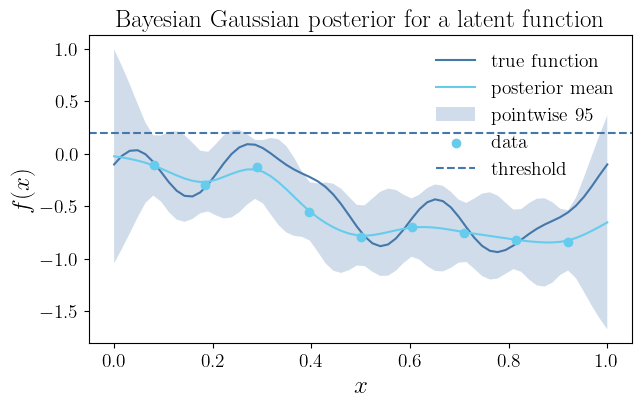

In [4]:
post_sd = np.sqrt(np.diag(post_cov))

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(t_grid, f_true(t_grid), label="true function")
ax.plot(t_grid, post_mean, label="posterior mean")
ax.fill_between(
    t_grid,
    post_mean - 1.96 * post_sd,
    post_mean + 1.96 * post_sd,
    alpha=0.25,
    label="pointwise 95% band",
)
ax.scatter(x_obs, y_obs, zorder=5, label="data")
ax.axhline(threshold, linestyle="--", label="threshold")

ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title("Bayesian Gaussian posterior for a latent function")
ax.legend(loc="best")

if nb.SAVEFIGS:
    nb.savefig("posterior_gp_example")
plt.show()

# Quantity of interest: posterior probability that the curve stays below the threshold

In [5]:
def direct_integrand(u):
    u = np.asarray(u)
    u = np.clip(u, np.finfo(float).eps, 1 - np.finfo(float).eps)
    z = stats.norm.ppf(u)
    f_samples = post_mean + z @ L_post.T
    return np.all(f_samples <= threshold, axis=1).astype(float)

def estimate_integral(u):
    vals = direct_integrand(u)
    return vals.mean(), vals.std(ddof=1) / math.sqrt(len(vals))

## First crude Monte Carlo check

In [6]:
n = 2**12
u_mc = qp.IIDStdUniform(d_grid)(n)
p_hat, se_hat = estimate_integral(u_mc)

print(f"Based on n = {n} samples")
print(f"The estimated probability of being within tolerance is = {p_hat:.5f} +/- {1.96*se_hat:.5f}")

Based on n = 4096 samples
The estimated probability of being within tolerance is = 0.53296 +/- 0.01528


## Crude Sobol' check

In [15]:
crude_sobol = qp.CustomFun(qp.Uniform(qp.Sobol(d_grid)), direct_integrand)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", MaxSamplesWarning)
    crude_sobol_sol, crude_sobol_data = qp.CubQMCNetG(crude_sobol, abs_tol=1e-12, n_init = n, n_limit=n).integrate()
print(f"n = {n}")
print(f"Sobol' estimate = {crude_sobol_sol:.5f} +/- {crude_sobol_data.comb_bound_diff/2:.5f}")

n = 1024
Sobol' estimate = 0.52734 +/- 0.00314


In [8]:
u = qp.Sobol(3, randomize=True, replications=2)(4)
print(u.shape)

(2, 4, 3)


## Randomized replicate comparison: MC versus scrambled Sobol'

In [9]:
print(colors)
mc_color = colors["blue"]
sobol_color = colors["green"]

{'blue': '#4477AA', 'cyan': '#66CCEE', 'green': '#228833', 'yellow': '#CCBB44', 'red': '#EE6677', 'purple': '#AA3377', 'grey': '#BBBBBB'}


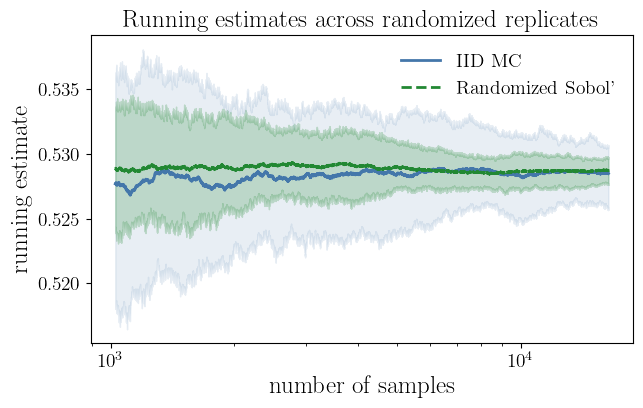

MC final sd: 0.0036633923270910527
Sobol final sd: 0.0013652925997504482
sd ratio MC/Sobol: 2.6832287289630496


In [10]:
def replicate_running_means(distribution, n, r):
    u = distribution(n)

    if u.ndim == 2:
        u = u.reshape(1, *u.shape)

    r_actual, n_actual, d_actual = u.shape
    vals = direct_integrand(u.reshape(r_actual * n_actual, d_actual))
    vals = vals.reshape(r_actual, n_actual)

    return np.cumsum(vals, axis=1) / np.arange(1, n_actual + 1)

n = 2**14
r = 100

iid_dist = qp.IIDStdUniform(d_grid, replications=r)
sobol_dist = qp.Sobol(d_grid, randomize=True, replications=r)

mc_running = replicate_running_means(iid_dist, n, r)
sobol_running = replicate_running_means(sobol_dist, n, r)

mc_color = colors["blue"]
sobol_color = colors["green"]

def plot_running_band(
    ax,
    running,
    label=None,
    color=None,
    fill_hw=0.25,
    linestyle="-",
    linewidth=2,
    alpha=0.18,
    n_min_plot=100,
):
    k = np.arange(1, running.shape[1] + 1)
    mask = k >= n_min_plot

    center = running.mean(axis=0)
    qlo = np.quantile(running, 0.5-fill_hw, axis=0)
    qup = np.quantile(running, 0.5+fill_hw, axis=0)

    ax.plot(
        k[mask],
        center[mask],
        label=label,
        color=color,
        linestyle=linestyle,
        linewidth=linewidth,
    )

    ax.fill_between(
        k[mask],
        qlo[mask],
        qup[mask],
        color=color,
        alpha=alpha,
    )

fig, ax = plt.subplots(figsize=(7, 4))

n_min_plt=2**10

plot_running_band(ax, mc_running, "IID MC", color=mc_color, alpha = 0.12, n_min_plot=n_min_plt)
plot_running_band(ax, sobol_running, "Randomized Sobol'", color=sobol_color, alpha=0.22, linestyle="--", n_min_plot=n_min_plt)

ax.set_xscale("log")
ax.set_xlabel("number of samples")
ax.set_ylabel("running estimate")
ax.set_title("Running estimates across randomized replicates")
ax.legend(loc="best")

if nb.SAVEFIGS:
    nb.savefig("running_estimates_mc_vs_sobol_from_100")

plt.show()

print("MC final sd:", mc_running[:, -1].std(ddof=1))
print("Sobol final sd:", sobol_running[:, -1].std(ddof=1))
print("sd ratio MC/Sobol:", mc_running[:, -1].std(ddof=1) / sobol_running[:, -1].std(ddof=1))

In [11]:
# Randomized replicate comparison: MC versus scrambled Sobol'

def mc_replicates(n, r, seed=12345):
    rng_local = np.random.default_rng(seed)
    estimates = np.empty(r)
    for k in range(r):
        u = rng_local.random((n, d_grid))
        estimates[k] = direct_integrand(u).mean()
    return estimates

def sobol_replicates(n, r, seed=12345):
    estimates = np.empty(r)
    for k in range(r):
        sobol = stats.qmc.Sobol(d=d_grid, scramble=True, seed=seed + k)
        u = sobol.random(n)
        estimates[k] = direct_integrand(u).mean()
    return estimates

n = 2**10
r = 64

est_mc = mc_replicates(n, r)
est_sobol = sobol_replicates(n, r)

summary = {
    "MC mean": est_mc.mean(),
    "MC sd": est_mc.std(ddof=1),
    "Sobol mean": est_sobol.mean(),
    "Sobol sd": est_sobol.std(ddof=1),
    "sd ratio MC/Sobol": est_mc.std(ddof=1) / est_sobol.std(ddof=1),
}

summary

{'MC mean': np.float64(0.52783203125),
 'MC sd': np.float64(0.01478370498285911),
 'Sobol mean': np.float64(0.5306854248046875),
 'Sobol sd': np.float64(0.008275082197253513),
 'sd ratio MC/Sobol': np.float64(1.786532705109056)}

TypeError: savefig() takes 1 positional argument but 2 were given

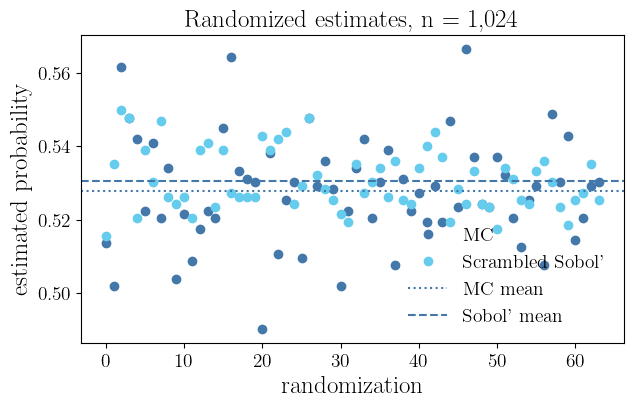

In [12]:
# Plot randomized estimates

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(est_mc, "o", label="MC")
ax.plot(est_sobol, "o", label="Scrambled Sobol'")
ax.axhline(est_mc.mean(), linestyle=":", label="MC mean")
ax.axhline(est_sobol.mean(), linestyle="--", label="Sobol' mean")

ax.set_xlabel("randomization")
ax.set_ylabel("estimated probability")
ax.set_title(f"Randomized estimates, n = {n:,}")
ax.legend(loc="best")

cl.nbviz.savefig(fig, "mc_vs_sobol_randomized_estimates")
plt.show()